# UnconBacktest Example: TS Momentum in Cryptocurrencies

We will run a simple "uncon backtest" to test whether 4 of the larger coins (BTC, ETH, ADA, BNB) show time-series momentum. In other words, if they have done well recently, do they tend to continue to do well?

1. Run the first cell to compute returns for these coins since 2016.
2. The signal on each day for each coin will be: sqrt(10)*(avg past 10 day ret - avg past 365 day ret) / (stdev past 365 day ret). You can think of this as the z-score of the past 10 day returns, and it tells us if a coin is doing better than it usually does. Technical note: we multiply by sqrt(10) here because the stdev is calculated on daily data but we want to "z-score" the average 10 day returns.
3. The signal from (2) will have extreme values. Pass them through a tanh function to curtail these. These are your final daily portfolio weights.
4. Compute the returns to the weights from (3). 
5. What is the Sharpe of these strategies? Plot their cumulative returns.
6. How correlated are the timing strategies with the underlying assets?

In [6]:
# compute returns 
import yfinance as yf 
import numpy as np

##Run the first cell to compute returns for these coins since 2016.
data = yf.download(['ADA-USD','BNB-USD','BTC-USD','ETH-USD'],'2016-1-1')
ret = data['Close'] / data['Close'].shift() - 1

[*********************100%***********************]  4 of 4 completed


In [7]:
ret

Ticker,ADA-USD,BNB-USD,BTC-USD,ETH-USD
Date,,,,
2016-01-01,NaN,NaN,NaN,NaN
2016-01-02,NaN,NaN,-0.002063,NaN
2016-01-03,NaN,NaN,-0.007907,NaN
2016-01-04,NaN,NaN,0.007163,NaN
2016-01-05,NaN,NaN,-0.002611,NaN
...,...,...,...,...
2026-07-06,-0.028168,-0.005946,0.007036,0.008170
2026-07-07,-0.051833,-0.014753,-0.010901,-0.016167
2026-07-08,-0.043515,-0.014720,-0.016428,-0.014608


In [8]:
# The signal on each day for each coin will be: sqrt(10)*(avg past 10 day ret - avg past 365 day ret) / (stdev past 365 day ret). 
#You can think of this as the z-score of the past 10 day returns, and it tells us if a coin is doing better than it usually does. 
#Technical note: we multiply by sqrt(10) here because the stdev is calculated on daily data but we want to "z-score" the average 10 day returns.

# The signal from (2) will have extreme values. Pass them through a tanh function to curtail these. These are your final daily portfolio weights.
port = np.sqrt(10)*(ret.rolling(10, min_periods=1).mean() - ret.rolling(365, min_periods=10).mean())
port = port/ret.rolling(365, min_periods=10).std()
port = np.tanh(port)
strat_ret = port.shift()*ret 
strat_ret

Ticker,ADA-USD,BNB-USD,BTC-USD,ETH-USD
Date,,,,
2016-01-01,NaN,NaN,NaN,NaN
2016-01-02,NaN,NaN,NaN,NaN
2016-01-03,NaN,NaN,NaN,NaN
2016-01-04,NaN,NaN,NaN,NaN
2016-01-05,NaN,NaN,NaN,NaN
...,...,...,...,...
2026-07-06,-0.027701,-0.003092,0.005518,0.006889
2026-07-07,-0.049698,-0.005258,-0.008674,-0.013677
2026-07-08,-0.040705,-0.005817,-0.012171,-0.011827


In [9]:
# What is the Sharpe of these strategies?

strat_ret.mean()/strat_ret.std()*np.sqrt(365)

Ticker
ADA-USD    0.555602
BNB-USD    0.743464
BTC-USD    0.582274
ETH-USD    0.669204
dtype: float64

<Axes: xlabel='Date'>

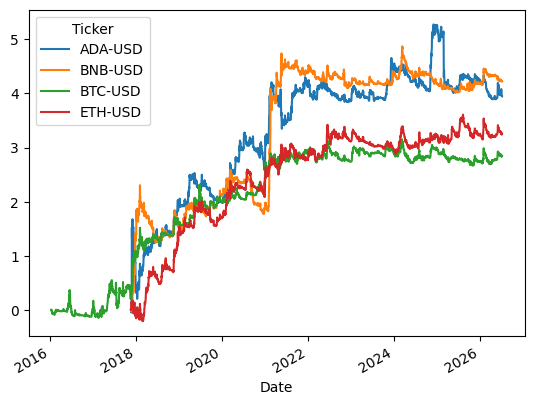

In [10]:
# What is the Sharpe of these strategies? Plot their cumulative returns.
strat_ret.cumsum().plot()

In [12]:
# correlations with underlying assets. Fairly lowly correlated, 
# suggesting we could enhance a buy and hold strategy with TS momentum
strat_ret.corrwith(ret)

Ticker
ADA-USD    0.061588
BNB-USD    0.139323
BTC-USD   -0.132083
ETH-USD   -0.160932
dtype: float64